## **Crop Yield Prediction Model**

**Loading the dataset**

In [ ]:
import pandas as pd

df = pd.read_csv("crop_yield_dataset.csv")

df.head()

,Crop,Temperature (C),Rainfall (mm),Humidity (%),Sunlight (hours),Soil pH,Soil Nitrogen (%),Soil Phosphorus (ppm),Soil Potassium (ppm),Altitude (m),Wind Speed (m/s),Crop Yield (tons/ha)
0,Sugarcane,34.913575,775.152185,74.578370,8.774801,6.837498,0.699950,11.888733,20.011258,471.457113,9.763327,16.431548
1,Potato,35.811066,818.508666,32.727748,5.467236,6.412727,1.549513,11.479175,18.736874,1854.966039,2.092408,15.716563
2,Maize,24.561550,1974.846329,52.673403,10.879523,7.540923,1.400999,5.198974,38.266053,1711.700243,5.781248,17.604874
3,Rice,32.105826,1160.228741,28.542676,7.961415,5.603166,2.318641,8.881700,29.875669,969.547674,7.801020,18.001099
4,Barley,15.782832,1763.427162,51.482789,7.161202,8.279977,1.954544,9.898112,27.113319,1586.461067,14.417580,22.477403


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Crop                   30000 non-null  object 
 1   Temperature (C)        30000 non-null  float64
 2   Rainfall (mm)          30000 non-null  float64
 3   Humidity (%)           30000 non-null  float64
 4   Sunlight (hours)       30000 non-null  float64
 5   Soil pH                30000 non-null  float64
 6   Soil Nitrogen (%)      30000 non-null  float64
 7   Soil Phosphorus (ppm)  30000 non-null  float64
 8   Soil Potassium (ppm)   30000 non-null  float64
 9   Altitude (m)           30000 non-null  float64
 10  Wind Speed (m/s)       30000 non-null  float64
 11  Crop Yield (tons/ha)   30000 non-null  float64
dtypes: float64(11), object(1)
memory usage: 2.7+ MB


In [ ]:
df.describe()

,Temperature (C),Rainfall (mm),Humidity (%),Sunlight (hours),Soil pH,Soil Nitrogen (%),Soil Phosphorus (ppm),Soil Potassium (ppm),Altitude (m),Wind Speed (m/s),Crop Yield (tons/ha)
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000
mean,27.451218,1251.982891,55.118190,7.982949,6.999881,1.498264,12.490973,25.047180,1516.261312,7.514672,20.147398
std,7.202059,433.352880,20.171186,2.326903,0.865826,0.576847,4.317733,8.635854,851.466110,4.337548,4.153447
min,15.001778,500.003447,20.010449,4.000540,5.500158,0.500059,5.000084,10.000068,50.026448,0.000541,6.125014
25%,21.266108,877.140792,37.692582,5.947181,6.250950,0.999107,8.765295,17.622589,779.587417,3.743507,17.247584
50%,27.428006,1251.735792,55.198862,7.977138,7.000118,1.495794,12.487247,25.016558,1504.594696,7.553594,20.148749
75%,33.709337,1627.527420,72.500277,9.997014,7.748959,1.993632,16.226607,32.538474,2251.125171,11.262246,23.072378
max,39.999938,1999.948861,89.998252,11.999536,8.499998,2.499905,19.999582,39.999279,2999.778101,14.998919,33.343344


In [ ]:
df.isnull().sum()

,0
Crop,0
Temperature (C),0
Rainfall (mm),0
Humidity (%),0
Sunlight (hours),0
Soil pH,0
Soil Nitrogen (%),0
Soil Phosphorus (ppm),0
Soil Potassium (ppm),0
Altitude (m),0


The dataset was found to be complete with no missing values; therefore, imputation was not required.

# **Data Preprocessing**

**Separate features and target**

In [ ]:
df.columns


Index(['Crop', 'Temperature (C)', 'Rainfall (mm)', 'Humidity (%)',
       'Sunlight (hours)', 'Soil pH', 'Soil Nitrogen (%)',
       'Soil Phosphorus (ppm)', 'Soil Potassium (ppm)', 'Altitude (m)',
       'Wind Speed (m/s)', 'Crop Yield (tons/ha)'],
      dtype='object')

In [ ]:
X = df.drop("Crop Yield (tons/ha)", axis=1)
y = df["Crop Yield (tons/ha)"]

**Identify categorical and numerical columns**

In [ ]:
num_cols = X.select_dtypes(include=["int64", "float64"]).columns
cat_cols = X.select_dtypes(include=["object"]).columns

Define Variables

In [ ]:
categorical_cols = ['Crop']

numerical_cols = [
    'Temperature (C)',
    'Rainfall (mm)',
    'Humidity (%)',
    'Sunlight (hours)',
    'Soil pH',
    'Soil Nitrogen (%)',
    'Soil Phosphorus (ppm)',
    'Soil Potassium (ppm)',
    'Altitude (m)',
    'Wind Speed (m/s)'
]

**Encoding Applied**

In [ ]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(drop="first", sparse_output=False)

encoded_cat = encoder.fit_transform(X[cat_cols])

In [ ]:
encoded_cat_df = pd.DataFrame(
    encoded_cat,
    columns=encoder.get_feature_names_out(cat_cols)
)

In [ ]:
X_final = pd.concat(
    [X[num_cols].reset_index(drop=True),
     encoded_cat_df.reset_index(drop=True)],
    axis=1
)

**Feature Scaling**

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_final)

X_scaled = pd.DataFrame(X_scaled, columns=X_final.columns)

In [ ]:
X_scaled

,Temperature (C),Rainfall (mm),Humidity (%),Sunlight (hours),Soil pH,Soil Nitrogen (%),Soil Phosphorus (ppm),Soil Potassium (ppm),Altitude (m),Wind Speed (m/s),Crop_Cotton,Crop_Maize,Crop_Peanut,Crop_Potato,Crop_Rice,Crop_Soybean,Crop_Sugarcane,Crop_Tomato,Crop_Wheat
0,1.036159,-1.100347,0.964767,0.340309,-0.187549,-1.383950,-0.139483,-0.583151,-1.227085,0.518425,-0.332839,-0.334320,-0.331974,-0.333950,-0.331788,-0.334505,3.019610,-0.336534,-0.335305
1,1.160777,-1.000297,-1.110040,-1.081160,-0.678155,0.088844,-0.234339,-0.730722,0.397797,-1.250097,-0.332839,-0.334320,-0.331974,2.994458,-0.331788,-0.334505,-0.331169,-0.336534,-0.335305
2,-0.401235,1.668099,-0.121204,1.244840,0.624896,-0.168619,-1.688877,1.530722,0.229536,-0.399639,-0.332839,2.991145,-0.331974,-0.333950,-0.331788,-0.334505,-0.331169,-0.336534,-0.335305
3,0.646299,-0.211734,-1.317521,-0.009255,-1.613186,1.422196,-0.835933,0.559131,-0.642096,0.066017,-0.332839,-0.334320,-0.331974,-0.333950,3.013973,-0.334505,-0.331169,-0.336534,-0.335305
4,-1.620173,1.180222,-0.180230,-0.353157,1.478492,0.791002,-0.600525,0.239255,0.082447,1.591457,-0.332839,-0.334320,-0.331974,-0.333950,-0.331788,-0.334505,-0.331169,-0.336534,-0.335305
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,-0.520154,0.533526,0.799404,-0.605158,1.148753,1.087542,1.721391,-0.717652,0.677768,-1.626751,-0.332839,-0.334320,-0.331974,-0.333950,-0.331788,-0.334505,-0.331169,2.971468,-0.335305
29996,0.010286,-0.525092,-0.516003,1.699490,-0.128510,-0.238381,-0.792004,1.296085,1.717636,-0.014766,-0.332839,-0.334320,-0.331974,-0.333950,-0.331788,-0.334505,-0.331169,2.971468,-0.335305
29997,-0.040680,1.690645,1.721393,0.476076,-1.008548,-0.765558,0.456462,-0.426982,-1.162199,-0.675127,3.004453,-0.334320,-0.331974,-0.333950,-0.331788,-0.334505,-0.331169,-0.336534,-0.335305
29998,-1.514009,-0.940014,1.578879,-1.660376,-0.280366,1.534328,1.019961,1.384737,0.127998,1.118388,-0.332839,-0.334320,-0.331974,2.994458,-0.331788,-0.334505,-0.331169,-0.336534,-0.335305


Train–Test Split

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2,
    random_state=42
)

Train Linear Regression (Baseline Model)

In [ ]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

lr_preds = lr.predict(X_test)

Train Decision Tree Regressor

In [ ]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)

dt_preds = dt.predict(X_test)

Model Evaluation

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

def evaluate(y_test, preds, model_name):
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)

    print(f"{model_name} Results:")
    print("MAE:", mae)
    print("RMSE:", rmse)
    print("R²:", r2)
    print("----------------------")

evaluate(y_test, lr_preds, "Linear Regression")
evaluate(y_test, dt_preds, "Decision Tree")

Linear Regression Results:
MAE: 2.5243196918245965
RMSE: 2.9086609738838454
R²: 0.5219225939522599
----------------------
Decision Tree Results:
MAE: 3.4535796596171666
RMSE: 4.240341944799972
R²: -0.016046937823714913
----------------------


The Decision Tree model produced a negative R² score, indicating that its predictions perform worse than a naive baseline that simply predicts the mean crop yield. This suggests that the model failed to generalize to unseen data. A likely cause is overfitting, where the tree captures noise and training-specific patterns rather than true underlying relationships. Such behavior is common in unconstrained decision trees, which require hyperparameter tuning (e.g., limiting depth) to improve generalization.

In [ ]:
dt = DecisionTreeRegressor(
    max_depth=5,
    random_state=42
)

dt.fit(X_train, y_train)
dt_preds = dt.predict(X_test)

evaluate(y_test, dt_preds, "Decision Tree (Depth=5)")

Decision Tree (Depth=5) Results:
MAE: 2.711946074945397
RMSE: 3.226161791316643
R²: 0.4118551503493051
----------------------


In [ ]:
dt = DecisionTreeRegressor(
    max_depth=3,
    random_state=42
)

dt.fit(X_train, y_train)
dt_preds = dt.predict(X_test)

evaluate(y_test, dt_preds, "Decision Tree (Depth=5)")

Decision Tree (Depth=5) Results:
MAE: 2.841217139632292
RMSE: 3.4101563513476703
R²: 0.34285592861861935
----------------------


Initially, the Decision Tree model exhibited overfitting, resulting in poor test performance. By limiting tree depth, model generalization improved significantly. A depth of 5 produced the best tree performance, while a depth of 3 led to underfitting. Despite improvements, Linear Regression achieved superior results, indicating that the dataset exhibits predominantly linear relationships.

Feature Importance (From Depth=5 Tree)

In [ ]:
importance = dt.feature_importances_

feature_importance_df = pd.DataFrame({
    "Feature": X_scaled.columns,
    "Importance": importance
}).sort_values(by="Importance", ascending=False)

feature_importance_df.head(10)

,Feature,Importance
2,Humidity (%),0.518437
0,Temperature (C),0.260264
1,Rainfall (mm),0.221299
3,Sunlight (hours),0.000000
4,Soil pH,0.000000
5,Soil Nitrogen (%),0.000000
6,Soil Phosphorus (ppm),0.000000
7,Soil Potassium (ppm),0.000000
8,Altitude (m),0.000000
9,Wind Speed (m/s),0.000000


Prediction vs Actual Plot

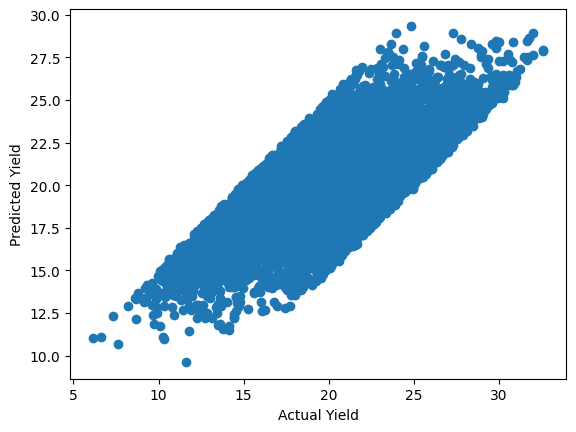

In [ ]:
plt.figure()
plt.scatter(y_test, lr_preds)
plt.xlabel("Actual Yield")
plt.ylabel("Predicted Yield")
plt.show()

Residual Analysis

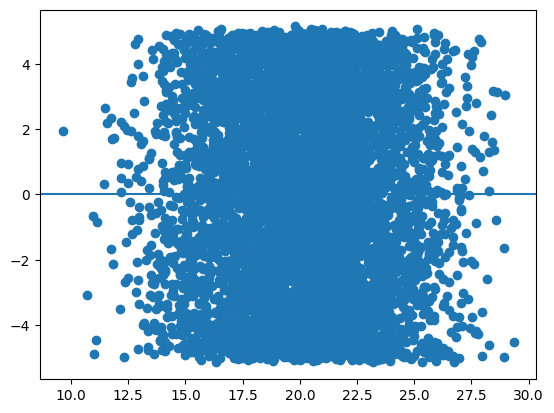

In [ ]:
residuals = y_test - lr_preds

plt.figure()
plt.scatter(lr_preds, residuals)
plt.axhline(y=0)
plt.show()

 **Final Model**

In [ ]:
final_model = lr

In [ ]:

import joblib
joblib.dump(final_model, "model.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(encoder, "encoder.pkl")

['encoder.pkl']

In [ ]:
import joblib

encoder = joblib.load("encoder.pkl")
scaler = joblib.load("scaler.pkl")
model = joblib.load("model.pkl")

In [ ]:
import pandas as pd

new_data = pd.DataFrame([{
    "Soil_Type": "Loamy",
    "Crop": "Wheat",
    "Rainfall": 120,
    "pH": 6.5,
    "Fertilizer": 80
}])

Build New Input Correctly

In [ ]:
new_data = pd.DataFrame([{
    'Crop': 'Wheat',
    'Temperature (C)': 25,
    'Rainfall (mm)': 120,
    'Humidity (%)': 65,
    'Sunlight (hours)': 8,
    'Soil pH': 6.5,
    'Soil Nitrogen (%)': 0.35,
    'Soil Phosphorus (ppm)': 18,
    'Soil Potassium (ppm)': 140,
    'Altitude (m)': 300,
    'Wind Speed (m/s)': 2.1
}])

Encoding

In [ ]:
encoded_features = encoder.transform(new_data[categorical_cols])

encoded_df = pd.DataFrame(
    encoded_features,
    columns=encoder.get_feature_names_out()
)

Combine Features

In [ ]:
final_input = pd.concat(
    [new_data[numerical_cols], encoded_df],
    axis=1
)

Scaling

In [ ]:
final_input_scaled = pd.DataFrame(
    final_input_scaled,
    columns=final_input.columns
)

prediction = model.predict(final_input_scaled)

**Prediction**


Estimated crop production per hectare of land(tons/ha)

In [ ]:
prediction = model.predict(final_input_scaled)

print("Predicted Yield:", prediction)

Predicted Yield: [22.16658465]


The model predicts that under the given soil and weather conditions, the crop is expected to produce approximately 22.17 tons of output from one hectare of farmland.

**Decide Category Thresholds**

In [ ]:
print(y.describe())

count    30000.000000
mean        20.147398
std          4.153447
min          6.125014
25%         17.247584
50%         20.148749
75%         23.072378
max         33.343344
Name: Crop Yield (tons/ha), dtype: float64


Create Yield Categories

In [ ]:
low_thresh = y.quantile(0.25)
high_thresh = y.quantile(0.75)

def categorize_yield(value):
    if value < low_thresh:
        return "Low Yield"
    elif value < high_thresh:
        return "Medium Yield"
    else:
        return "High Yield"

Apply To Prediction

In [ ]:
predicted_yield = prediction[0]

category = categorize_yield(predicted_yield)

print("Predicted Yield:", round(predicted_yield, 2), "tons/ha")
print("Yield Category:", category)

Predicted Yield: 22.17 tons/ha
Yield Category: Medium Yield


Yield categories were derived from the regression output using quantile-based thresholds, allowing meaningful interpretation of predicted productivity levels.